# Classificação Multiclasse

## Introdução

Este arquivo tem como objetivo desenvolver um modelo de classificação capaz de identificar estrelas (estrela, quasar e galáxia) com base em suas características espectrais.

## Conjunto de Dados

O conjunto de dados foi obtido através do Kaggle (https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17/data) e contém informações como valores de filtros (ultravioleta, verde, vermelho) e *redshift*.

# Imports e Upload do Dataset

Inserção da raiz do projeto no *sys.path* para permitir o *import* do *wrapper* de classificação multiclasse:

In [9]:
from pathlib import Path
import sys

ROOT = Path.cwd()

while not (ROOT / "wrappers").exists():
    # print(sys.path[0])
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

*Imports* necessários:

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)

from wrappers.multiclass import NeuralNetworkMulticlassClassifier

*Upload* do conjunto de dados:

In [11]:
df = pd.read_csv("../datasets/star_classification.csv")

# Análise Exploratória dos Dados

Nesta etapa, foi realizada uma análise exploratória para compreender a estrutura e as principais características do conjunto de dados. Para isso, serão utilizadas algumas funções do *DataFrame*, que permitem obter informações relevantes sobre o *dataset*:

* **`head()`**: exibe os cinco primeiros registros do conjunto de dados;
* **`info()`**: apresenta informações gerais, como os nomes dos atributos, a quantidade de valores não nulos e o tipo de dado de cada coluna;
* **`describe()`**: fornece estatísticas descritivas das variáveis numéricas, incluindo contagem, média, desvio padrão, valores mínimo, máximo e quartis;
* **`isnull().sum()`**: calcula a quantidade de valores ausentes (*missing values*) em cada atributo.

In [5]:
print("\nHead:")
display(df.head())
print("\nInfo:")
display(df.info())
print("\nDescribe:")
display(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())
print("\nDistribuição das classes:")
print(df['class'].value_counts())


Head:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str

None


Describe:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000



Valores nulos:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Distribuição das classes:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


## Significado de Cada Coluna

| Coluna | Descrição |
|--------|-----------|
| **obj_ID** | Identificador único do objeto |
| **alpha** | Ângulo de ascensão reta |
| **delta** | Ângulo de declinação |
| **u** | Filtro ultravioleta |
| **g** | Filtro verde |
| **r** | Filtro vermelho |
| **i** | Filtro infravermelho próximo |
| **z** | Filtro infravermelho |
| **run_ID** | Identificador de execução |
| **rerun_ID** | Identificador de reprocessamento |
| **cam_col** | Coluna da câmera |
| **field_ID** | Identificador de campo |
| **spec_obj_ID** | Identificador espectroscópico |
| **class** | **Alvo:** GALAXY, STAR ou QSO |
| **redshift** | Desvio para o vermelho (redshift) |
| **plate** | Identificador do prato do espectrôgrafo |
| **MJD** | Data da observação (Modified Julian Date) |
| **fiber_ID** | Identificador da fibra óptica |

Para complementar a análise exploratória, foram gerados gráficos de alguns atributos do *dataset*, possibilitando uma melhor compreensão da distribuição e do comportamento dos dados:

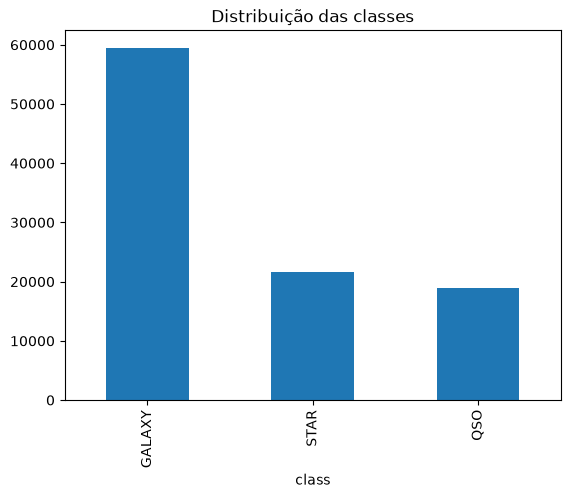

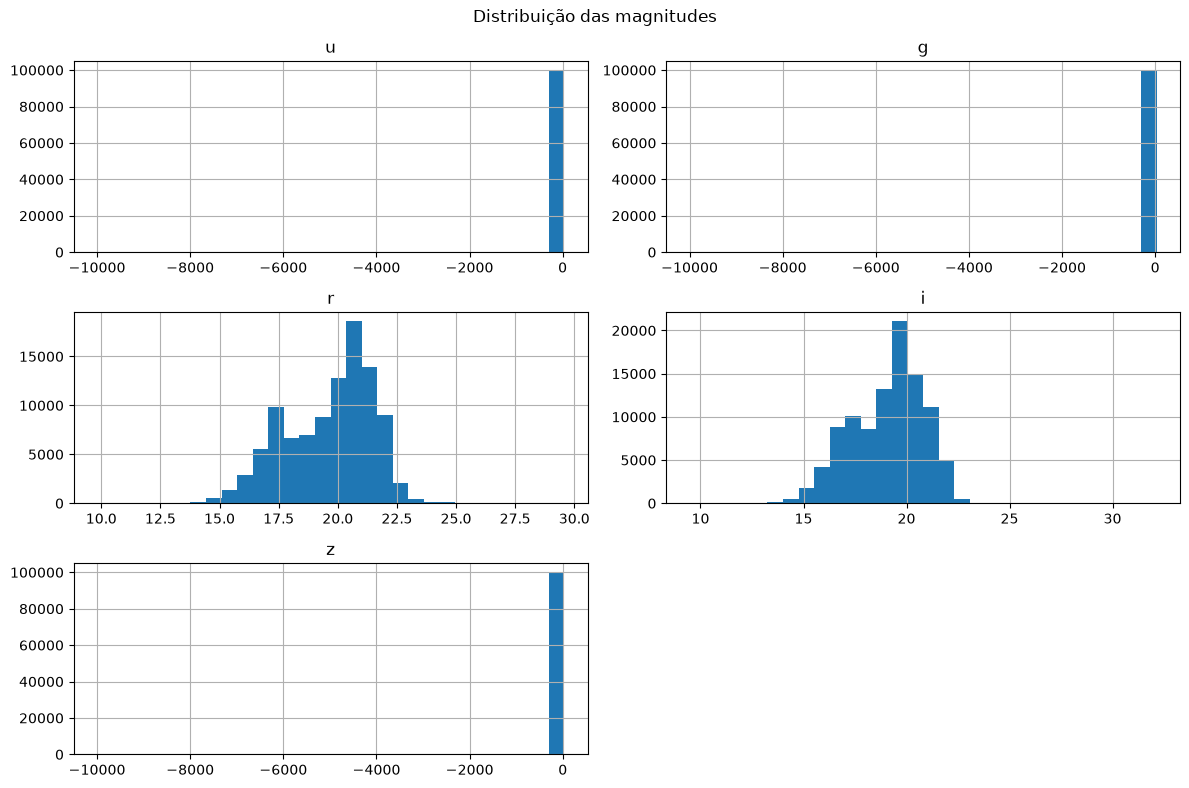

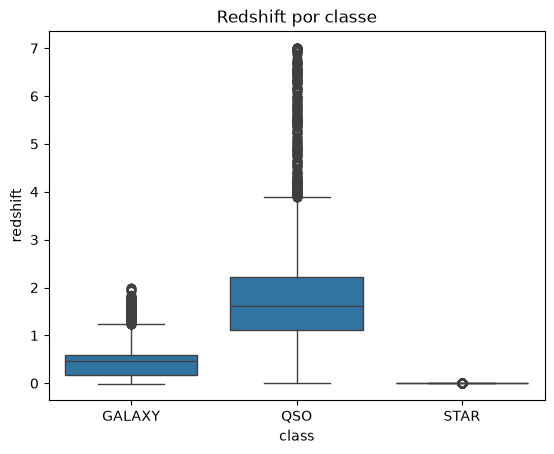

In [23]:
df['class'].value_counts().plot(kind='bar')
plt.title("Distribuição das classes")
plt.show()

features = ["u", "g", "r", "i", "z"]
df[features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribuição das magnitudes")
plt.tight_layout()
plt.show()

sns.boxplot(data=df, x="class", y="redshift")
plt.title("Redshift por classe")
plt.show()


# Tratamento dos Dados

Nesta etapa, foi realizado o pré-processamento do conjunto de dados. Inicialmente, foram definidas as variáveis preditoras e a variável alvo (*class*), removendo atributos considerados pouco relevantes para a tarefa de classificação. Em seguida, a variável alvo foi convertida para valores numéricos por meio da técnica de *Label Encoding*, tornando-a adequada para os algoritmos de aprendizado de máquina. Por fim, foi definido um *pipeline* de pré-processamento para tratar valores ausentes utilizando a mediana e normalizar os atributos numéricos, preparando os dados para o treinamento dos modelos.

In [5]:
# X = Drop de todas as colunas pouco significativas para o problema.
X = df.drop(
    columns=[
        "obj_ID",
        "alpha",
        "delta",
        "run_ID",
        "rerun_ID",
        "cam_col",
        "field_ID",
        "fiber_ID",
        "class",
    ]
)
display(X.head())

# y = Objetivo.
y = df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Preencher valores faltantes com a mediana e normalizar.
preprocessor = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

,u,g,r,i,z,spec_obj_ID,redshift,plate,MJD
0,23.87882,22.27530,20.39501,19.16573,18.79371,6.543777e+18,0.634794,5812,56354
1,24.77759,22.83188,22.58444,21.16812,21.61427,1.176014e+19,0.779136,10445,58158
2,25.26307,22.66389,20.60976,19.34857,18.94827,5.152200e+18,0.644195,4576,55592
3,22.13682,23.77656,21.61162,20.50454,19.25010,1.030107e+19,0.932346,9149,58039
4,19.43718,17.58028,16.49747,15.97711,15.54461,6.891865e+18,0.116123,6121,56187


# Treinamento

Nesta etapa, o conjunto de dados foi dividido em dois subconjuntos: treinamento (80%) e teste (20%), utilizando uma divisão estratificada para preservar a proporção das classes da variável alvo. Em seguida, foram definidos os modelos de classificação que seriam avaliados: uma Rede Neural Multicamadas (MLP), uma *Random Forest* (RF), um *HistGradientBoosting* (HG) e a Rede Neural implementada neste trabalho. Para cada modelo, foram especificados os hiperparâmetros selecionados na etapa de [Escolha dos Hiperparâmetros](#extra-escolha-dos-hiperparâmetros).

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        solver="adam",
        activation="relu",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=3000,
        random_state=42,
    ),
    "RF": RandomForestClassifier(
        n_estimators=500,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="log2",
        max_depth=20,
        random_state=42,
    ),
    "HG": HistGradientBoostingClassifier(
        min_samples_leaf=20,
        max_iter=200,
        max_depth=10,
        learning_rate=0.05,
        l2_regularization=0.1,
        random_state=42,
    ),
    "NN (Our)": NeuralNetworkMulticlassClassifier(
        hidden_layers=(128, 64, 32),
        hidden_activation="tanh",
        learning_rate=0.01,
        epochs=1000,
        batch_size=32,
    )
}

Nesta etapa, cada modelo foi integrado ao *pipeline* de pré-processamento e treinado utilizando o conjunto de treinamento. Após o treinamento, os modelos foram avaliados no conjunto de teste por meio da realização de predições e do cálculo das probabilidades de classificação. Para cada algoritmo, foram registradas métricas de desempenho, incluindo acurácia, precisão, *recall*, *F1-score* (considerando média *macro*) e área sob a curva ROC (ROC-AUC com estratégia *one-vs-rest*), além dos tempos de treinamento e de inferência. Os resultados obtidos foram consolidados para posterior análise comparativa entre os modelos. Por fim, foi gerado o relatório de classificação e a matriz de confusão, permitindo uma avaliação detalhada do desempenho de cada abordagem.


 MLP
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11889
           1       0.97      0.93      0.95      3792
           2       0.95      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



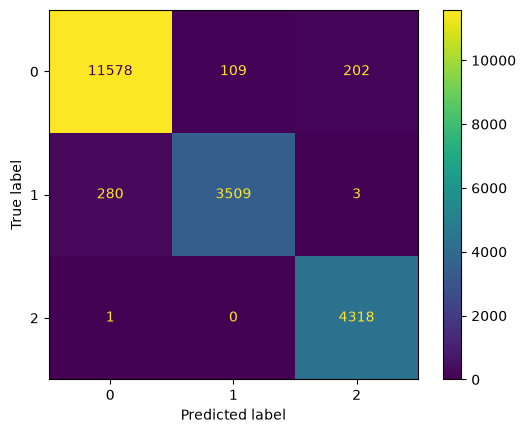


 RF
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11889
           1       0.97      0.93      0.95      3792
           2       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



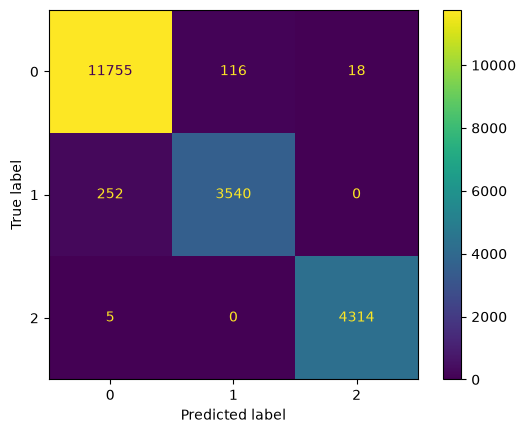


 HG
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11889
           1       0.96      0.94      0.95      3792
           2       0.99      0.99      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



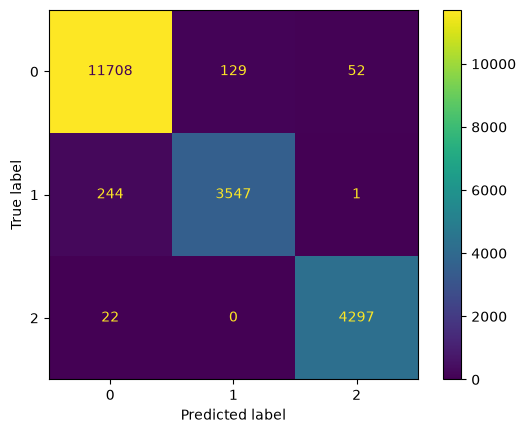


 NN (Our)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11889
           1       0.96      0.93      0.95      3792
           2       0.98      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



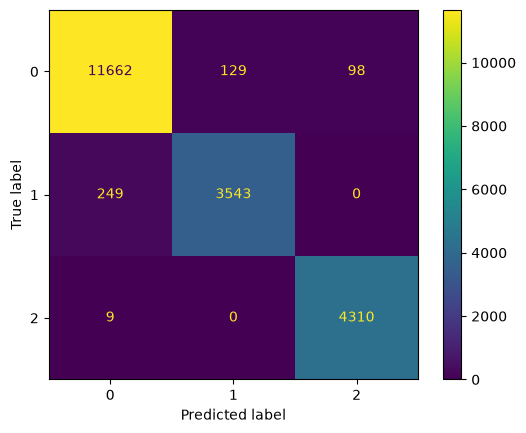

In [18]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = pipeline.predict(X_test)
    elapsed = time.time() - start

    y_prob = pipeline.predict_proba(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')
    f1   = f1_score(y_test, y_pred, average='macro')
    auc  = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr',
        average='macro'
    )

    results.append([name, acc, prec, rec, f1, auc, train_time, elapsed])

    print("\n", name)
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

Após a avaliação dos modelos, os resultados obtidos foram organizados em uma tabela comparativa, reunindo as principais métricas de desempenho e os tempos de treinamento e inferência de cada algoritmo. Em seguida, foi gerado um gráfico de barras para facilitar a comparação visual entre os modelos, destacando métricas como acurácia, *F1-Macro*, ROC-AUC e tempo de treinamento.

,Modelo,Accuracy,Precision,Recall,F1-Macro,ROC AUC,Tempo de Treinamento,Tempo de Inferência
0,MLP,0.97025,0.966951,0.966326,0.966291,0.994155,58.972168,0.078260
1,RF,0.98045,0.980907,0.973705,0.977191,0.995889,110.383797,0.911058
2,HG,0.97760,0.976836,0.971691,0.974179,0.995853,1.749758,0.122004
3,NN (Our),0.97575,0.973664,0.971053,0.972242,0.994811,600.064478,0.043286


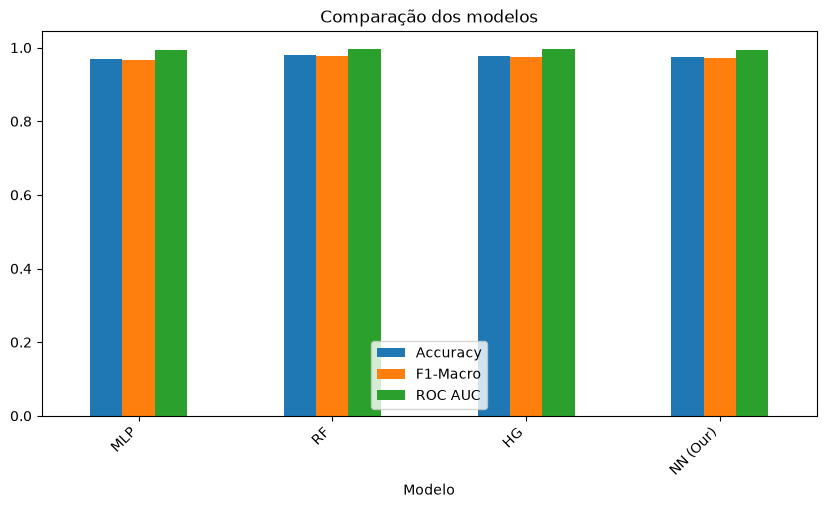

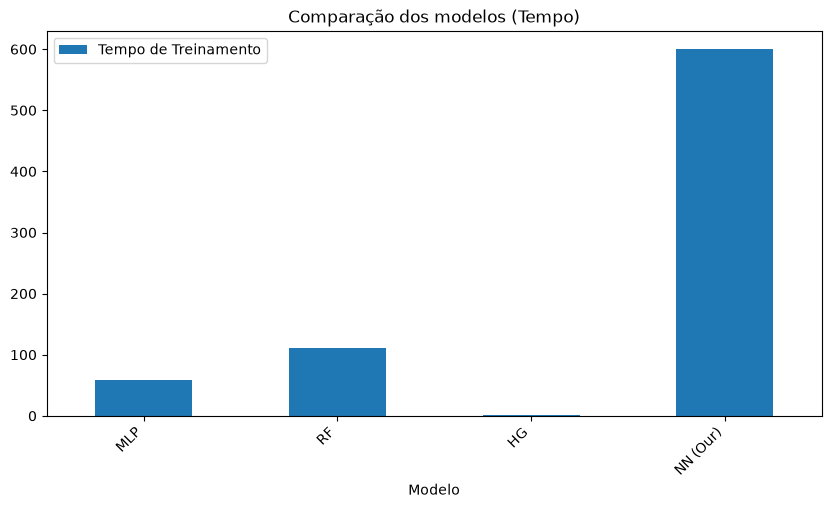

In [21]:
# Resultados em uma tabela comparativa
results_df = pd.DataFrame(
    results,
    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Macro",
        "ROC AUC",
        "Tempo de Treinamento",
        "Tempo de Inferência",
    ],
)

display(results_df)

# Gráfico das métricas
results_df.plot(x="Modelo", y=["Accuracy", "F1-Macro", "ROC AUC"], kind="bar", figsize=(10, 5))
plt.xticks(rotation=45, ha='right')
plt.title("Comparação dos modelos")
plt.show()

results_df.plot(x="Modelo", y=["Tempo de Treinamento"], kind="bar", figsize=(10, 5))
plt.xticks(rotation=45, ha='right')
plt.title("Comparação dos modelos (Tempo)")
plt.show()

# Conclusão

Os resultados obtidos demonstram que todos os modelos apresentaram excelente desempenho na tarefa de classificação, com acurácia superior a 97% e valores elevados de *F1-Macro* e *ROC-AUC*. O *Random Forest* (RF) destacou-se como o modelo de melhor desempenho geral, alcançando a maior acurácia (98.05%), o maior *F1-Macro* (0.9772) e o maior *ROC-AUC* (0.9959), evidenciando elevada capacidade de classificação e generalização.

O *HistGradientBoosting* (HG) apresentou desempenho muito próximo ao do *Random Forest*, porém com um tempo de treinamento de apenas 1.75 s, tornando-se a alternativa mais eficiente do ponto de vista computacional. A MLP também apresentou resultados competitivos, com menor custo de treinamento que o *Random Forest*.

A rede neural desenvolvida neste trabalho (NN) obteve métricas de classificação semelhantes às dos demais modelos, alcançando 97.58% de acurácia e F1-Macro de 0.9722. Entretanto, esse ganho não foi suficiente para justificar seu elevado custo computacional. Seu tempo de treinamento foi de aproximadamente 600 segundos (10 minutos), cerca de 340 vezes maior que o do *HistGradientBoosting*, 10 vezes maior que o da MLP e 5 vezes maior que o do *Random Forest*, sem apresentar melhoria nas métricas de desempenho. Embora tenha registrado o menor tempo de inferência, essa diferença foi pequena e pouco significativa quando comparada ao aumento expressivo no tempo de treinamento.

De forma geral, os resultados indicam que o *Random Forest* foi o modelo mais eficaz em termos de desempenho preditivo, enquanto o *HistGradientBoosting* apresentou a melhor relação entre desempenho e eficiência computacional. Já a rede neural proposta mostrou que, para este conjunto de dados, o elevado custo de treinamento não se traduziu em ganhos de desempenho, tornando sua utilização menos vantajosa em comparação aos demais modelos avaliados.

# Extra: Escolha dos Hiperparâmetros

Nesta etapa, foi realizada a otimização dos hiperparâmetros dos modelos de classificação com o objetivo de identificar as configurações que proporcionam melhor desempenho. Para cada algoritmo, foi definido um *pipeline* contendo o pré-processamento dos dados e o classificador correspondente, além de um conjunto de hiperparâmetros candidatos. A busca foi realizada utilizando o método *Randomized Search* com validação cruzada de cinco *folds* (*5-fold Cross Validation*), avaliando diferentes combinações de hiperparâmetros de forma aleatória. Como critério de seleção, foi utilizada a métrica *F1-Macro*. Ao final do processo, foram registrados o melhor valor de F1 obtido durante a validação cruzada e a combinação de hiperparâmetros correspondente para cada modelo.

In [7]:
mlp_pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("model", MLPClassifier(max_iter=3000, random_state=42, early_stopping=True)),
    ]
)

mlp_params = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-4, 1e-3, 1e-2],
    "model__solver": ["adam", "sgd"],
}

rf_pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ]
)

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

hgb_pipeline = Pipeline(
    [("prep", preprocessor), ("model", HistGradientBoostingClassifier(random_state=42))]
)

hgb_params = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_iter": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_leaf": [10, 20, 50],
    "model__l2_regularization": [0.0, 0.1, 0.5],
}

nn_pipeline = Pipeline(
    [("prep", preprocessor), ("model", NeuralNetworkMulticlassClassifier())]
)

nn_params = {
    "model__hidden_layers": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "model__hidden_activation": [
        "relu",
        "sigmoid",
        "tanh",
        "leaky_relu",
        "elu",
        "selu",
    ],
    "model__learning_rate": [
        0.00001,
        0.0001,
        0.001,
        0.01,
    ],
    "model__epochs": [200, 500, 1000, 3000],
    "model__batch_size": [None, 8, 16, 32, 64],
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from math import prod


def run_search(pipeline, params, n_iter=50):
    total_combinations = prod(len(v) for v in params.values())

    search = RandomizedSearchCV(
        pipeline,
        params,
        n_iter=min(n_iter, total_combinations),
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        random_state=42,
        verbose=0,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    return search


print("MLP - Buscando hiperparâmetros...")
mlp_search = run_search(mlp_pipeline, mlp_params, n_iter=30)
print(f"  Melhor F1-Macro: {mlp_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {mlp_search.best_params_}")

print("RF - Buscando hiperparâmetros...")
rf_search = run_search(rf_pipeline, rf_params)
print(f"  Melhor F1-Macro: {rf_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {rf_search.best_params_}")

print("GB - Buscando hiperparâmetros...")
hgb_search = run_search(hgb_pipeline, hgb_params)
print(f"  Melhor F1-Macro: {hgb_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {hgb_search.best_params_}")

print("NN - Buscando hiperparâmetros...")
nn_search = run_search(nn_pipeline, nn_params)
print(f"  Melhor F1-Macro: {nn_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {nn_search.best_params_}")

NN - Buscando hiperparâmetros...
  Melhor F1-Macro: 0.9699
  Melhores parâmetros:  {'model__learning_rate': 0.01, 'model__hidden_layers': (128, 64, 32), 'model__hidden_activation': 'tanh', 'model__epochs': 1000, 'model__batch_size': 32}
